In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [13]:
import pandas as pd
from sqlalchemy import create_engine
from src.config import settings

engine = create_engine(settings.database_url)

raw = pd.read_sql("""
    SELECT ticker, date, open, high, low, close, volume, adjusted_close, source
    FROM daily_prices
    WHERE source = 'yfinance'
""", engine)

processed = pd.read_csv("../data/processed/v1/features_all_tickers.csv")

raw["date"] = pd.to_datetime(raw["date"])
processed["date"] = pd.to_datetime(processed["date"])

print("Raw tickers:", sorted(raw["ticker"].unique()))
print("Processed tickers:", sorted(processed["ticker"].unique()))

merged = processed.merge(
    raw,
    on=["ticker", "date"],
    how="left",
    suffixes=("_processed", "_raw"),
)

print("Processed rows with missing raw match:", merged["open_raw"].isna().sum())

Raw tickers: ['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']
Processed tickers: ['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']
Processed rows with missing raw match: 0


In [14]:
print(sorted(processed["ticker"].unique()))

['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']


In [16]:
processed[processed['ticker'] == 'AAPL'].head()

,ticker,date,open,high,low,close,volume,adjusted_close,source,return_1d,return_5d,return_10d,return_20d,volatility_5d,volatility_20d,volatility_ratio_5d_20d,high_low_range_pct,close_open_return,drawdown_20d
0,AAPL,2021-08-19,145.029999,148.000000,144.500000,146.699997,86960300,143.210358,yfinance,0.002323,-0.014709,-0.002448,-0.000681,0.014472,0.010473,1.381921,0.023858,0.011515,-0.029248
1,AAPL,2021-08-20,147.440002,148.500000,146.779999,148.190002,60549600,144.664902,yfinance,0.010157,-0.006103,0.014028,-0.002491,0.015604,0.010370,1.504750,0.011607,0.005087,-0.019389
2,AAPL,2021-08-23,148.309998,150.190002,147.889999,149.710007,60131800,146.148758,yfinance,0.010257,-0.009330,0.024779,0.004833,0.014883,0.010609,1.402921,0.015363,0.009440,-0.009330
3,AAPL,2021-08-24,149.449997,150.860001,149.149994,149.619995,48606400,146.060852,yfinance,-0.000601,-0.003795,0.027610,0.019418,0.014681,0.009995,1.468893,0.011429,0.001137,-0.009926
4,AAPL,2021-08-25,149.809998,150.320007,147.800003,148.360001,58991300,144.830856,yfinance,-0.008421,0.013665,0.017140,0.023314,0.007865,0.009765,0.805392,0.016986,-0.009679,-0.018264


Matplotlib is building the font cache; this may take a moment.


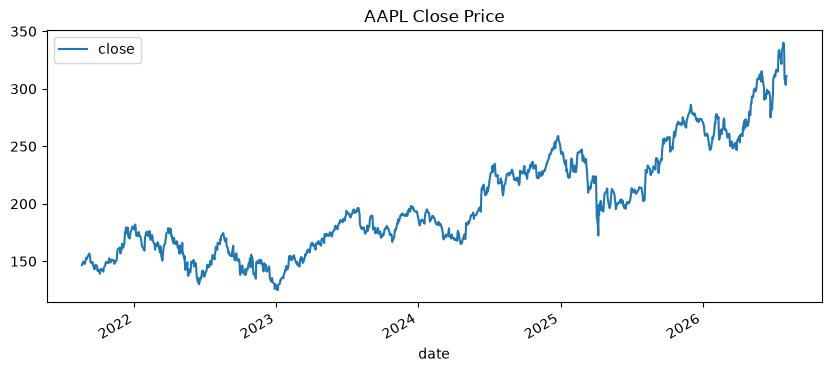

In [17]:
import matplotlib.pyplot as plt

aapl = processed[processed["ticker"] == "AAPL"].copy()
aapl["date"] = pd.to_datetime(aapl["date"])

aapl.plot(x="date", y="close", figsize=(10, 4), title="AAPL Close Price")
plt.show()